# **Лабораторная работа 1. Регрессия и метод главных компонента**

## **Введение**

### **Цель работы:** 
изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

### **Постановка задачи:**

1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента). 

5. Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

7. Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

## **Описание датасета**
Скачиваем из Kaggle открытый датасет в формате CSV. [1] 
Датасет indian_car_prices.csv - набор данных содержит информацию о различных автомобилях, включая марку, модель, год выпуска, возраст, пробег, объем двигателя, мощность, пробег, количество предыдущих владельцев, тип топлива, тип трансмиссии и цену. 

Изначальный датасет хранил 1 миллион записей для лучшей работы с данными возмем выборку из нее 5 тысяч записей.

Импортивуем библиотеку Pandas, откроем наш датасет и выведем первые записи датасета.

In [396]:
import pandas as pd

df = pd.read_csv('indian_car_prices.csv')
print(f"Количество записей: {df.shape[0]}\nКоличество характеристик: {df.shape[1]}")
df.head()

Количество записей: 5305
Количество характеристик: 13


,Car_ID,Brand,Model,Year,Age_Years,Kilometers_Driven,Engine_CC,Horsepower,Mileage_KMPL,Previous_Owners,Fuel_Type,Transmission,Price_Lakh
0,1,Nissan,Safari,2023,3,67851,1598,125.8,13.4,3,Petrol,Automatic,3.62
1,2,Nissan,Baleno,2023,3,112303,1199,105.7,13.1,1,Petrol,Manual,2.42
2,3,Toyota,Kushaq,2021,5,10476,1199,90.9,22.9,1,Diesel,Manual,3.35
3,4,Toyota,Kwid,2021,5,22640,1498,107.8,11.1,1,Petrol,Automatic,3.89
4,5,Maruti Suzuki,Alto K10,2017,9,77722,1997,144.8,17.5,1,Petrol,Manual,1.88


Всего 5305 записей без пропусков. Из 13 столбцов: 8 количественных, 5 категориальных. 
Все признаки подробно расписаны в таблице 1.

Таблица 1 – Описание признаков
| переменная | Тип | Подтип | Описание |
| ----------- | ----------- | ----------- | ----------- |
| Car ID | Категориальная | Номинальная | Уникальный идентификатор каждого автомобиля. Не является признаком автомобиля. |
| Brand | Категориальная | Номинальная | Производитель автомобиля. Порядка между значениями нет. | 
| Model | Категориальная | Номинальная | Модель автомобиля. Порядка между значениями нет. |
| Year | Количественная | Дискретная | Год выпуска автомобиля. Значение принимает только целые числа. |
| Age_Years | Количественная | Дискретная | Возраст автомобиля. Значения принимает только целые числа. | 
| Kilometers_Driven | Количественная | Дискретная | Пробег автомобиля. Значения принимает только целые числа. | 
| Engine_CC | Количественная | Дискретная | объем двигателя в кубических сантиметрах. Значения принимает только целые числа.|
| Horsepower | Количественная | Непрерывная | Мощность двигателя. Значения принимает только вещественные числа. |
| Mileage_KMPL | Количественная | Непрерывная | пробег в километрах на литр. Значения принимает только вещественные числа. |
| Previous_Owners | Количественная | Дискретная | количество предыдущих владельцев. Значения принимает только целые числа. |
| Fuel_Type | Категориальная | Номинальная | Тип топлива потребляемый автомобилем. Бензин, дизель или сжатый природный газ. |
| Transmission | Категориальная | Номинальная | Механическая или автоматическая коробка передач автомобиля.|
| **Price_Lakh** | Количественная | Непрерывная | **Целевая переменная** – Цена автомобиля в лакхах  (1 лакх = 100 000 INR). |


Из анализа следует удалить: Car Id, потому что не влияет на цену автомобиля; Brand и Model, так как будем рассматривать влияние только технических характеристик на итоговую цена автомобиля.

In [397]:
df = df.drop(columns=['Car_ID', 'Brand', 'Model'])
print(f"Количество записей: {df.shape[0]}\nКоличество характеристик: {df.shape[1]}")
df.columns.to_list()


Количество записей: 5305
Количество характеристик: 10


['Year',
 'Age_Years',
 'Kilometers_Driven',
 'Engine_CC',
 'Horsepower',
 'Mileage_KMPL',
 'Previous_Owners',
 'Fuel_Type',
 'Transmission',
 'Price_Lakh']

Размер датасета уменьшился до 5305 × 10. Все оставшиеся признаки либо числовые, либо категориальные с малым числом уровней, пригодные для One-Hot-Encoding.

### **Первичный анализ**
Проведем первичный анализ наших признаков.

In [398]:
print(df.describe(include='all'))

               Year    Age_Years  Kilometers_Driven    Engine_CC   Horsepower  \
count   5305.000000  5305.000000        5305.000000  5305.000000  5305.000000   
unique          NaN          NaN                NaN          NaN          NaN   
top             NaN          NaN                NaN          NaN          NaN   
freq            NaN          NaN                NaN          NaN          NaN   
mean    2021.053157     4.946843       82462.824128  1632.806598   118.219453   
std        2.577933     2.577933       44967.917930   412.110710    25.076794   
min     2017.000000     1.000000        5017.000000   998.000000    65.500000   
25%     2019.000000     3.000000       43401.000000  1199.000000    98.200000   
50%     2021.000000     5.000000       83230.000000  1498.000000   118.900000   
75%     2023.000000     7.000000      121873.000000  1997.000000   138.900000   
max     2025.000000     9.000000      159935.000000  2198.000000   167.100000   

        Mileage_KMPL  Previ

Вывод даёт сводку по всем признакам: 
- для числовых – количество значений, mean, std, квартили и границы.
- для категориальных – количество значений, число уникальных значений, наиболее частую категорию и её частоту.
- Также понимаем, что целевая переменная Price_Lakh лежит в диапазоне 1.25–9.04 (среднее ≈ 3.49).
 - категориальные признаки Fuel_Type и Transmission имеют 3 и 2 категории соответственно; числовые признаки разномасштабны, что требует стандартизации перед регрессией и PCA.

### **Визуализация распределений признаков и целевой переменной**
####  **Признаки**



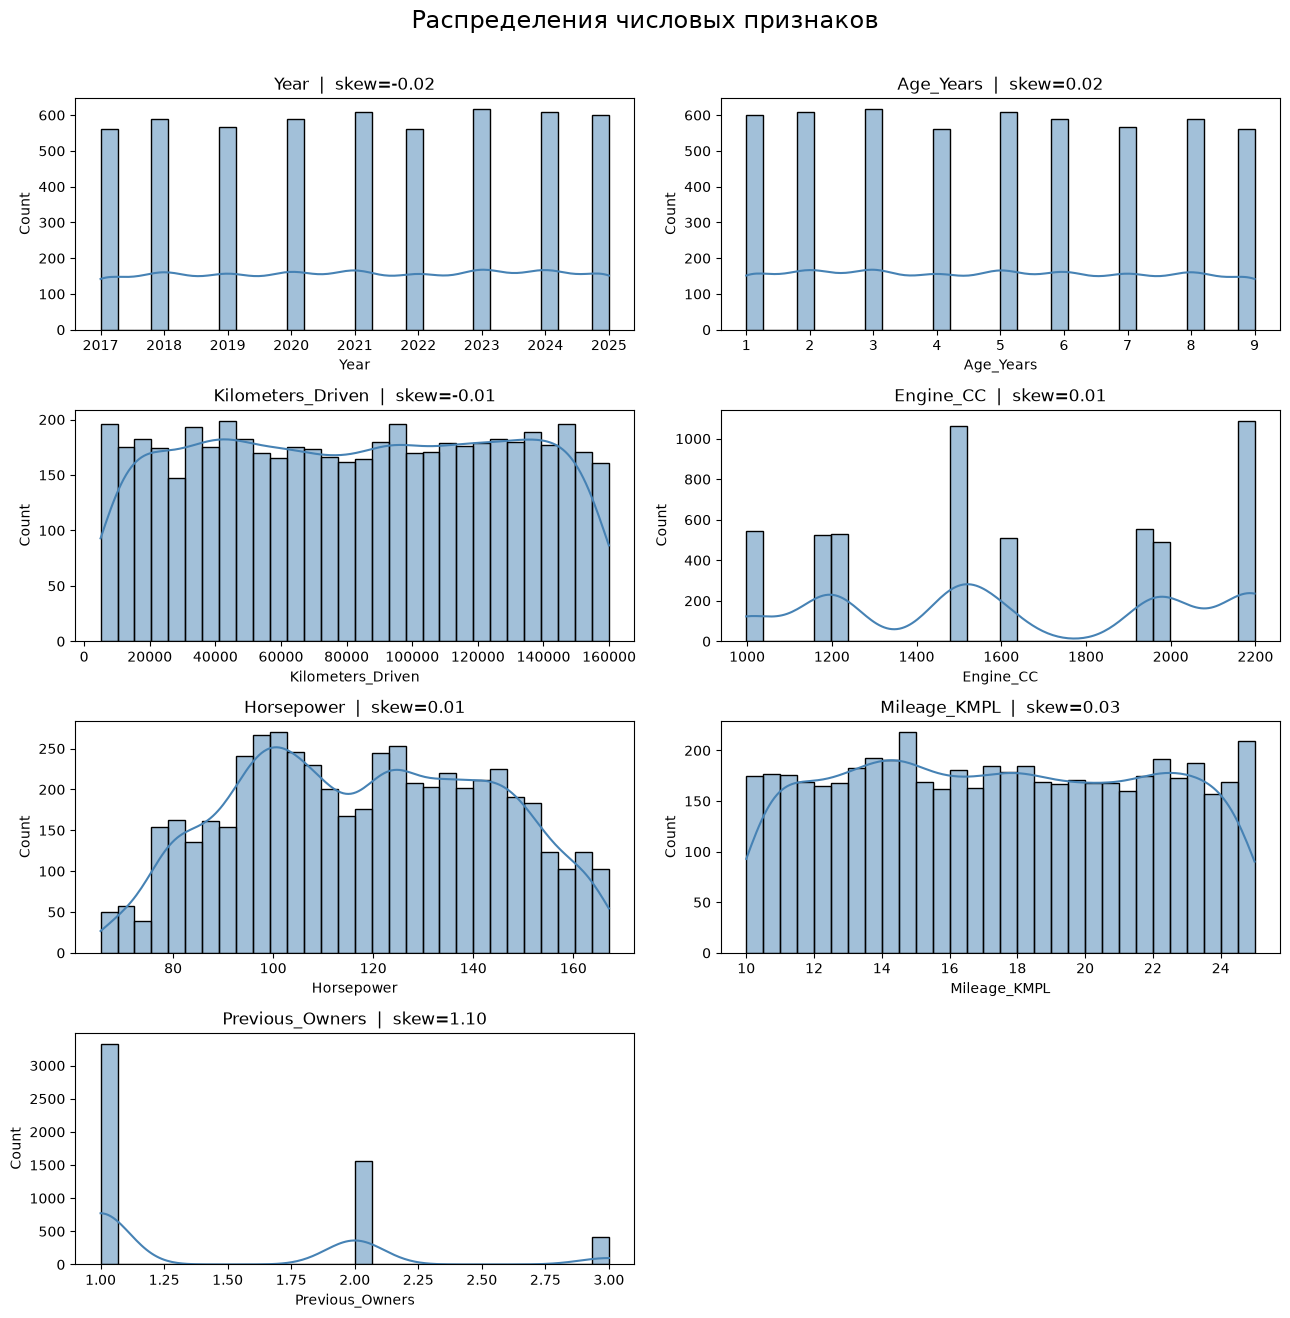

          Признак  W-статистика   p-value Нормальное?  Асимметрия  Эксцесс
             Year        0.9313 4.113e-43         Нет      -0.024   -1.230
        Age_Years        0.9313 4.113e-43         Нет       0.024   -1.230
Kilometers_Driven        0.9540 5.022e-37         Нет      -0.010   -1.218
        Engine_CC        0.8887 5.028e-51         Нет       0.009   -1.386
       Horsepower        0.9751 1.067e-28         Нет       0.007   -0.995
     Mileage_KMPL        0.9556 1.519e-36         Нет       0.026   -1.197
  Previous_Owners        0.6828 1.291e-70         Нет       1.099    0.081


In [399]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["Year", "Age_Years", "Kilometers_Driven", "Engine_CC",
            "Horsepower", "Mileage_KMPL", "Previous_Owners"]

fig, axes = plt.subplots(4, 2, figsize=(13, 13))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col}  |  skew={df[col].skew():.2f}")
for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")
plt.suptitle("Распределения числовых признаков", fontsize=17, y=1.01)
plt.tight_layout()
plt.show()

from scipy.stats import shapiro

norm_report = []
for col in num_cols:
    sample = df[col].sample(min(5000, len(df)), random_state=42)
    w, p = shapiro(sample)
    norm_report.append({
        "Признак": col,
        "W-статистика": round(w, 4),
        "p-value": f"{p:.3e}",
        "Нормальное?": "Да" if p > 0.05 else "Нет",
        "Асимметрия": round(df[col].skew(), 3),
        "Эксцесс": round(df[col].kurtosis(), 3),
    })
norm_df = pd.DataFrame(norm_report)
print(norm_df.to_string(index=False))

Вывод:
- Все признаки далеки от нормального закона распределения, что видно по гистограммам и по тесту Шапиро-Уилка (p-value < 0.05 для всех).
- Признаки Year, Age_Years, Kilometers_Driven, Mileage_KMPL, Engine_CC имеют распределение, близкое к равномерному.
- Horsepower имеет многовершинное распределение. Previous_Owners близко к экспоненциальному. Это означает, что модели линейной регрессии, предполагающие нормальность остатков, могут работать неоптимально.

#### **Целевая переменная**



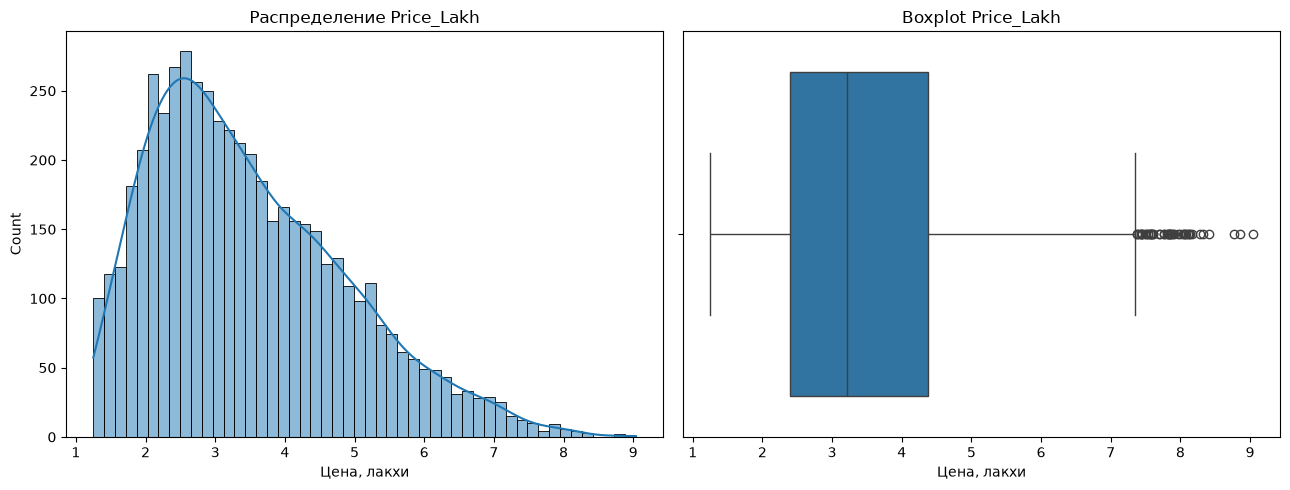

   Признак  W-статистика   p-value Нормальное?  Асимметрия  Эксцесс
Price_Lakh        0.9528 2.069e-37         Нет       0.751    0.095


In [400]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["Price_Lakh"], kde=True, bins=50, ax=axes[0])
axes[0].set_title("Распределение Price_Lakh")
axes[0].set_xlabel("Цена, лакхи")

sns.boxplot(x=df["Price_Lakh"], ax=axes[1])
axes[1].set_title("Boxplot Price_Lakh")
axes[1].set_xlabel("Цена, лакхи")
plt.tight_layout()
plt.show()

col = 'Price_Lakh'

norm_report = []
sample = df[col].sample(min(5000, len(df)), random_state=42)
w, p = shapiro(sample)
norm_report.append({
    "Признак": col,
    "W-статистика": round(w, 4),
    "p-value": f"{p:.3e}",
    "Нормальное?": "Да" if p > 0.05 else "Нет",
    "Асимметрия": round(df[col].skew(), 3),
    "Эксцесс": round(df[col].kurtosis(), 3),
})
norm_df = pd.DataFrame(norm_report)
print(norm_df.to_string(index=False))

Наша целевая переменная Price_Lakh не имеет нормального закона распределения (p-value = 2.07e-37). Она имеет правостороннюю асимметрию (0.75), что означает, что большинство автомобилей имеют цену ниже среднего, но есть небольшое количество очень дорогих автомобилей, которые «тянут» среднее вверх.

### **Предобработка данных**
#### **Проверка пропусков и дубликатов**


In [401]:
missing_total = df.isnull().sum().sum()
duplicates = df.duplicated().sum()
print(f"Пропусков всего: {missing_total}")
print(f"Дубликатов: {duplicates}")

Пропусков всего: 0
Дубликатов: 0


Из-за вывод следует, что в нашем датасете нет пропусков и дубликатов. Так что оставляем все как есть.

#### **Кодирование категориальных переменных**
Воспользуемся кодированием категориальных переменных One-Hot Encoding для категориальных признаков Fuel_Type и Transmission

In [402]:
cat_cols = ["Fuel_Type", "Transmission"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)
print("Размер после One-Hot:", df.shape)
print(df.dtypes.value_counts())

Размер после One-Hot: (5305, 11)
int64      8
float64    3
Name: count, dtype: int64


Итоговый размер датасета – (5305, 11). Теперь все признаки являются числовыми и готовы к дальнейшему анализу.
#### **Корреляционный анализ и мультиколлинеарность**

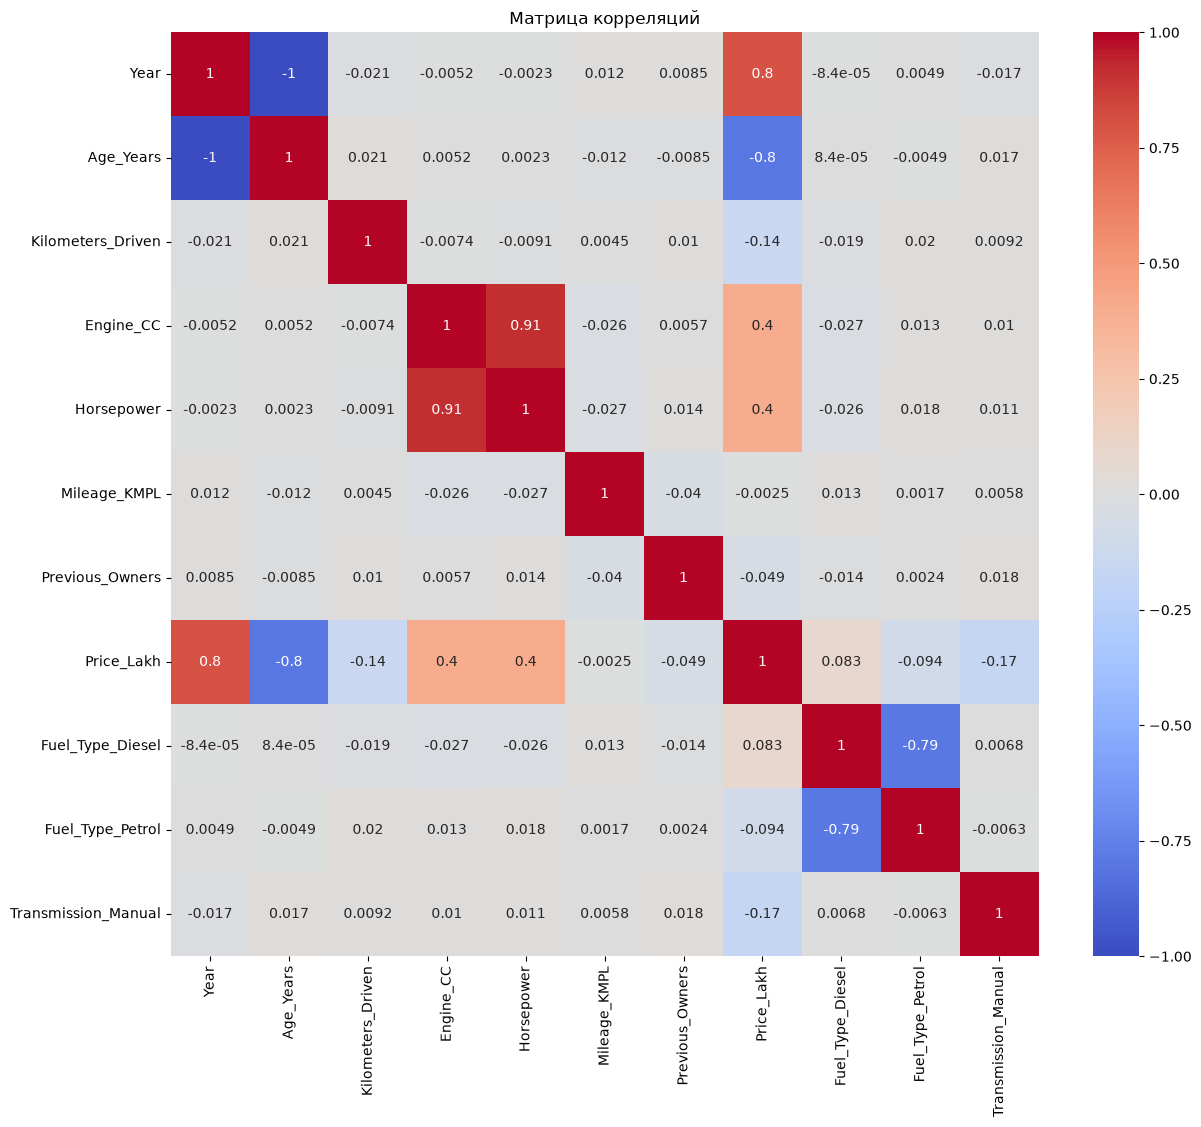

            Признак          VIF
               Year 1.000800e+15
          Age_Years 1.000800e+15
         Horsepower 6.133232e+00
          Engine_CC 6.133089e+00
   Fuel_Type_Diesel 2.657209e+00
   Fuel_Type_Petrol 2.655630e+00
       Mileage_KMPL 1.003022e+00
    Previous_Owners 1.002928e+00
  Kilometers_Driven 1.001180e+00
Transmission_Manual 1.000888e+00


C:\Users\dabac\AppData\Local\Temp\ipykernel_23436\1559499393.py:11: UserWarning: The design matrix is poorly conditioned (condition number=2.28e+14). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(X_for_vif.values, i)


In [403]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0, annot=True)
plt.title('Матрица корреляций')
plt.show()

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_for_vif = df.drop(columns=["Price_Lakh"])
vif_table = pd.DataFrame({
    "Признак": X_for_vif.columns,
    "VIF": [variance_inflation_factor(X_for_vif.values, i)
            for i in range(X_for_vif.shape[1])]
}).sort_values("VIF", ascending=False)
print(vif_table.to_string(index=False))

Из корреляционного анализа следует вывод:
- Engine_CC и Horsepower коррелируют на уровне 0.91, что подтверждается расчетом VIF: значения 6.57 и 6.40 соответственно. Это указывает на критическую мультиколлинеарность. 
- Признаки Year и Age_Years имеют VIF, близкий к бесконечности (из-за линейной зависимости: Age_Years = 2026 - Year), что делает невозможным использование стандартной линейной регрессии без устранения этой проблемы. 
- Остальные признаки по коэффициенту VIF не имеют мультиколлинеарности (VIF < 3).

# **Подготовка данных: разделение и стандартизация**


In [404]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price_Lakh"])
y = df["Price_Lakh"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}, Test: {X_test_sc.shape}")

Train: (4244, 10), Test: (1061, 10)


Мы разделили данные на обучающую (80%) и тестовую (20%) выборки с random_state=11 для воспроизводимости. Затем применили StandardScaler для стандартизации признаков. Важно, что fit_transform был вызван только на тренировочных данных, а transform – на тестовых, чтобы избежать утечки данных.

# **Ход работы**
## **Построение моделей регрессии (до PCA)**

In [405]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

def fit_and_score(estimator, X_tr, X_te, y_tr, y_te, name):
    estimator.fit(X_tr, y_tr)
    pred = estimator.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    mape = mean_absolute_percentage_error(y_te, pred) * 100
    mae = np.mean(np.abs(y_te - pred))
    return {
        "Модель": name,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R²": round(r2, 4),
        "MAPE, %": round(mape, 3),
        "predictions": pred,
    }

models_before = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.1)": Lasso(alpha=0.1),
}

rows_before = []
preds_before = {}
for name, mdl in models_before.items():
    res = fit_and_score(mdl, X_train_sc, X_test_sc, y_train, y_test, name)
    preds_before[name] = res.pop("predictions")
    rows_before.append(res)

metrics_before = pd.DataFrame(rows_before).set_index("Модель")
print("МЕТРИКИ МОДЕЛЕЙ НА ИСХОДНЫХ ПРИЗНАКАХ (до PCA)")
print("=" * 70)
print(metrics_before.to_string())

МЕТРИКИ МОДЕЛЕЙ НА ИСХОДНЫХ ПРИЗНАКАХ (до PCA)
                     RMSE     MAE      R²  MAPE, %
Модель                                            
Linear Regression  0.5051  0.3921  0.8680   13.052
Ridge (α=1.0)      0.5051  0.3921  0.8680   13.050
Lasso (α=0.1)      0.5517  0.4198  0.8426   13.170


Мы обучили три модели: линейную регрессию, Ridge и Lasso. Все модели показали высокие результаты, с R² около 0.87. Линейная и Ridge-регрессии показали практически идентичные метрики (RMSE ≈ 0.505, R² ≈ 0.868), в то время как Lasso немного уступает (R² = 0.843), что может быть связано с занулением коэффициентов.

## **Кросс-валидация моделей**


In [406]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=11)
cv_rows = []
for name, mdl in models_before.items():
    r2_scores = cross_val_score(mdl, X_train_sc, y_train, cv=kf, scoring="r2")
    rmse_scores = -cross_val_score(mdl, X_train_sc, y_train, cv=kf,
                                   scoring="neg_root_mean_squared_error")
    cv_rows.append({
        "Модель": name,
        "CV R² mean": round(r2_scores.mean(), 4),
        "CV R² std": round(r2_scores.std(), 4),
        "CV RMSE mean": round(rmse_scores.mean(), 4),
        "CV RMSE std": round(rmse_scores.std(), 4),
    })
cv_before = pd.DataFrame(cv_rows).set_index("Модель")
print(cv_before.to_string())

                   CV R² mean  CV R² std  CV RMSE mean  CV RMSE std
Модель                                                             
Linear Regression      0.8689     0.0038        0.5114       0.0086
Ridge (α=1.0)          0.8689     0.0038        0.5114       0.0086
Lasso (α=0.1)          0.8404     0.0071        0.5642       0.0173


Кросс-валидация с 5 фолдами подтвердила стабильность линейной и гребневой моделей (средний R² ≈ 0.868), в то время как у Lasso он был ниже (0.840). Это говорит о том, что модели не переобучены и показывают постоянные результаты на разных подвыборках.

## **Визуализация результатов до PCA**

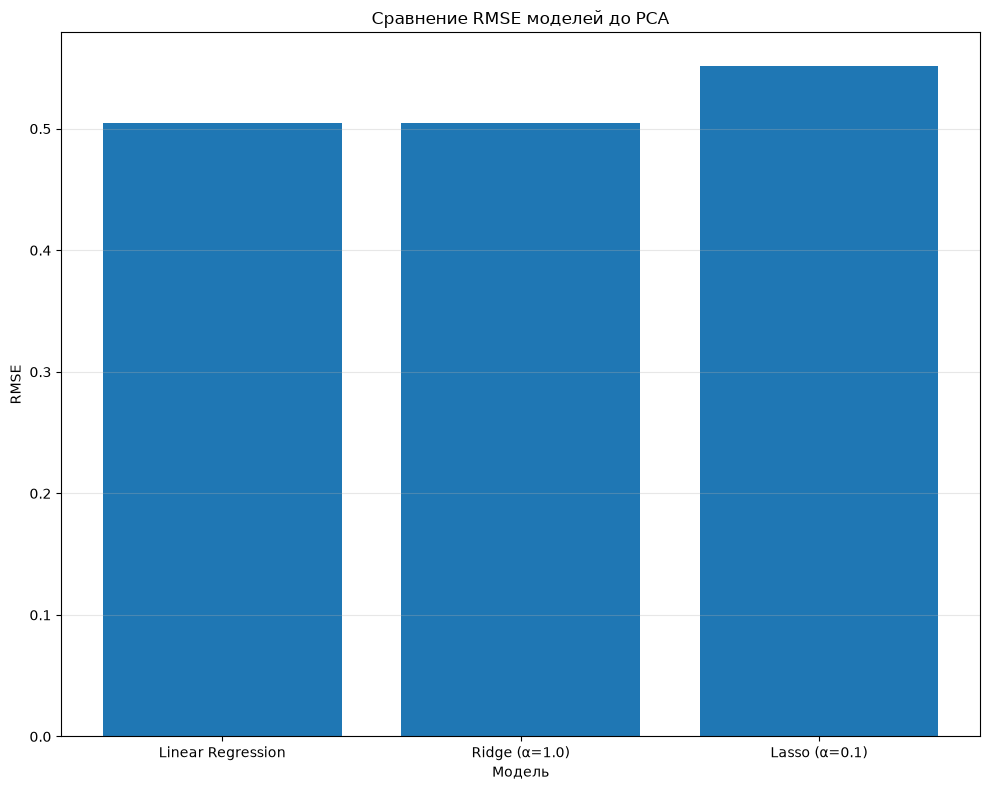

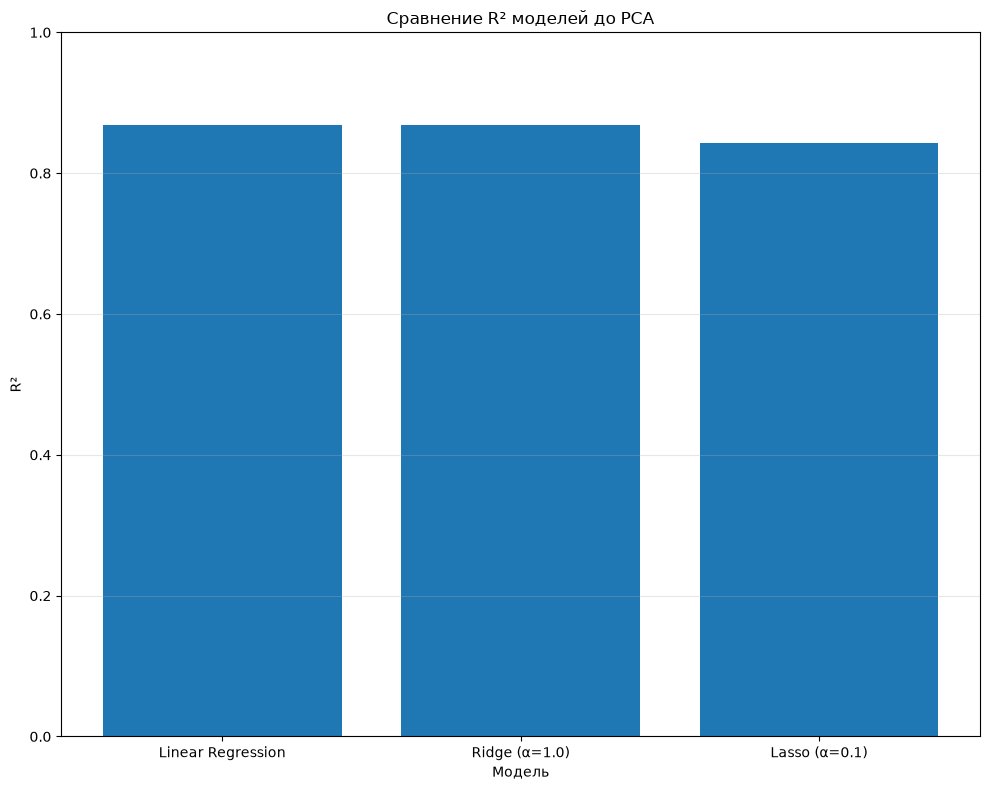

In [407]:
models = metrics_before.index.tolist()
rmse_values = metrics_before["RMSE"].values
r2_values = metrics_before["R²"].values

fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(models, rmse_values)
ax.set_title("Сравнение RMSE моделей до PCA")
ax.set_xlabel("Модель")
ax.set_ylabel("RMSE")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ax.bar(models, r2_values)
ax.set_title("Сравнение R² моделей до PCA")
ax.set_xlabel("Модель")
ax.set_ylabel("R²")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

На столбчатых диаграммах видно, что линейная регрессия и Ridge дают практически одинаковый RMSE (≈ 0.505), тогда как у Lasso ошибка заметно выше (≈ 0.552). Аналогичная картина по R²: Linear и Ridge — около 0.868, Lasso — 0.843. 

## **Устранение мультиколлинеарности с помощью PCA**

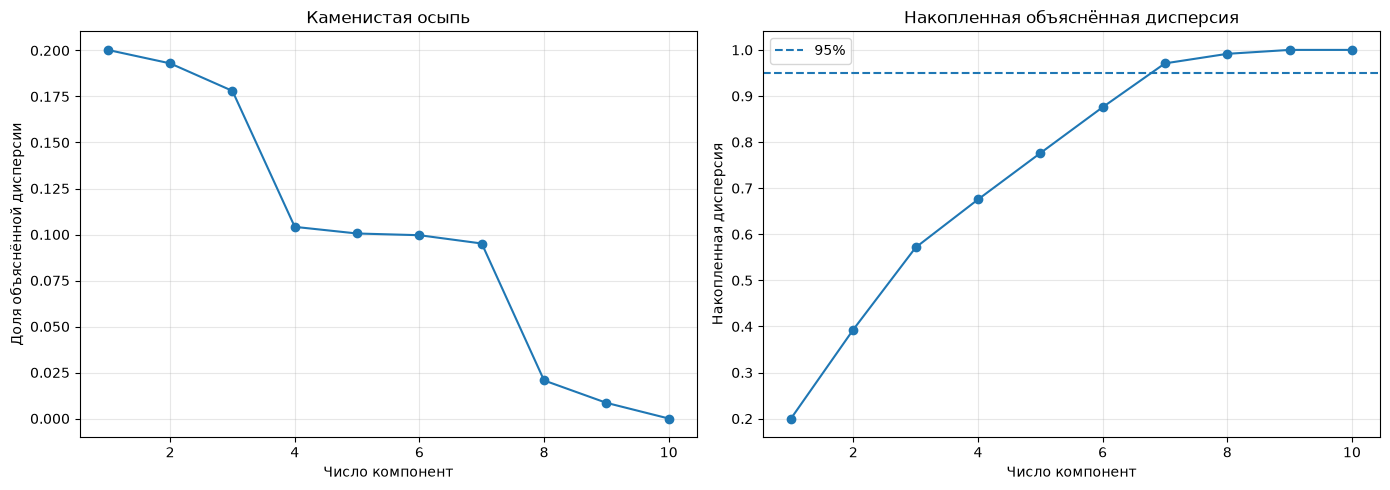

Для 95% дисперсии достаточно 7 компонент из 10


In [408]:
from sklearn.decomposition import PCA

pca_full = PCA().fit(X_train_sc)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(explained) + 1), explained, "o-")
axes[0].set_xlabel("Число компонент")
axes[0].set_ylabel("Доля объяснённой дисперсии")
axes[0].set_title("Каменистая осыпь")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(cumulative) + 1), cumulative, "o-")
axes[1].axhline(0.95, linestyle="--", label="95%")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная дисперсия")
axes[1].set_title("Накопленная объяснённая дисперсия")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

n_components_95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"Для 95% дисперсии достаточно {n_components_95} компонент из {X_train_sc.shape[1]}")

График каменистой осыпи и график накопленной дисперсии показывают, что для сохранения 95% информации достаточно 7 главных компонент (из 10 исходных). Это позволяет снизить размерность и устранить мультиколлинеарность.

In [409]:
pca = PCA(n_components=0.95, random_state=11)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

print(f"Исходных признаков: {X_train_sc.shape[1]}")
print(f"Главных компонент: {X_train_pca.shape[1]}")
print(f"Суммарная объяснённая дисперсия: {pca.explained_variance_ratio_.sum():.4f}")

Исходных признаков: 10
Главных компонент: 7
Суммарная объяснённая дисперсия: 0.9708


Мы применили PCA с n_components=0.95, что автоматически выбрало 7 главных компонент, объясняющих 97% дисперсии. Это подтверждает, что мы можем сократить размерность без значительной потери информации

## **Построение моделей регрессии (после PCA)**


In [410]:
models_after = {
    "Linear Regression": LinearRegression(),
    "Ridge (α=1.0)": Ridge(alpha=1.0),
    "Lasso (α=0.1)": Lasso(alpha=0.1),
}

rows_after = []
preds_after = {}
for name, mdl in models_after.items():
    res = fit_and_score(mdl, X_train_pca, X_test_pca, y_train, y_test, name)
    preds_after[name] = res.pop("predictions")
    rows_after.append(res)

metrics_after = pd.DataFrame(rows_after).set_index("Модель")
print("МЕТРИКИ МОДЕЛЕЙ НА ГЛАВНЫХ КОМПОНЕНТАХ (после PCA)")
print("=" * 70)
print(metrics_after.to_string())

МЕТРИКИ МОДЕЛЕЙ НА ГЛАВНЫХ КОМПОНЕНТАХ (после PCA)
                     RMSE     MAE      R²  MAPE, %
Модель                                            
Linear Regression  0.5062  0.3930  0.8675   13.104
Ridge (α=1.0)      0.5061  0.3930  0.8675   13.102
Lasso (α=0.1)      0.5376  0.4092  0.8505   12.979


После PCA линейная и Ridge-регрессии показали результаты, практически идентичные тем, что были до PCA (R² ≈ 0.8675). Это говорит о том, что PCA успешно справился с задачей, сохранив почти всю предсказательную способность модели. Lasso показала улучшение по сравнению с результатом до PCA (R² вырос с 0.8426 до 0.8505).

## **Кросс-валидация после PCA**

In [411]:
cv_rows_after = []
for name, mdl in models_after.items():
    r2_scores = cross_val_score(mdl, X_train_pca, y_train, cv=kf, scoring="r2")
    rmse_scores = -cross_val_score(mdl, X_train_pca, y_train, cv=kf,
                                   scoring="neg_root_mean_squared_error")
    cv_rows_after.append({
        "Модель": name,
        "CV R² mean": round(r2_scores.mean(), 4),
        "CV R² std": round(r2_scores.std(), 4),
        "CV RMSE mean": round(rmse_scores.mean(), 4),
        "CV RMSE std": round(rmse_scores.std(), 4),
    })
cv_after = pd.DataFrame(cv_rows_after).set_index("Модель")
print(cv_after.to_string())

                   CV R² mean  CV R² std  CV RMSE mean  CV RMSE std
Модель                                                             
Linear Regression      0.8686     0.0038        0.5119       0.0086
Ridge (α=1.0)          0.8686     0.0038        0.5119       0.0086
Lasso (α=0.1)          0.8490     0.0049        0.5488       0.0140


Кросс-валидация на главных компонентах показала, что линейная и Ridge-регрессии сохранили своё качество, а Lasso снизился в сотых значениях CV R².
## **Сравнительный анализ**

In [412]:
comparison = pd.concat(
    {"До PCA": metrics_before, "После PCA": metrics_after},
    axis=1
)
comparison.columns = [f"{stage}–{metric}" for stage, metric in comparison.columns]

print("СВОДНАЯ ТАБЛИЦА МЕТРИК: ДО И ПОСЛЕ PCA")
print("=" * 110)
print(comparison.to_string())

print()
delta = pd.DataFrame({
    "Модель": metrics_before.index,
    "ΔRMSE": (metrics_after["RMSE"].values - metrics_before["RMSE"].values).round(4),
    "ΔMAE": (metrics_after["MAE"].values - metrics_before["MAE"].values).round(4),
    "ΔR²": (metrics_after["R²"].values - metrics_before["R²"].values).round(4),
    "ΔMAPE": (metrics_after["MAPE, %"].values - metrics_before["MAPE, %"].values).round(3),
}).set_index("Модель")
print("Изменение метрик после PCA:")
print(delta.to_string())

СВОДНАЯ ТАБЛИЦА МЕТРИК: ДО И ПОСЛЕ PCA
                   До PCA–RMSE  До PCA–MAE  До PCA–R²  До PCA–MAPE, %  После PCA–RMSE  После PCA–MAE  После PCA–R²  После PCA–MAPE, %
Модель                                                                                                                               
Linear Regression       0.5051      0.3921     0.8680          13.052          0.5062         0.3930        0.8675             13.104
Ridge (α=1.0)           0.5051      0.3921     0.8680          13.050          0.5061         0.3930        0.8675             13.102
Lasso (α=0.1)           0.5517      0.4198     0.8426          13.170          0.5376         0.4092        0.8505             12.979

Изменение метрик после PCA:
                    ΔRMSE    ΔMAE     ΔR²  ΔMAPE
Модель                                          
Linear Regression  0.0011  0.0009 -0.0005  0.052
Ridge (α=1.0)      0.0010  0.0009 -0.0005  0.052
Lasso (α=0.1)     -0.0141 -0.0106  0.0079 -0.191


Сводная таблица показывает, что применение PCA практически не ухудшило качество лучших моделей (Linear и Ridge). Разница в R² составила менее 0.001. Lasso показала небольшое улучшение, что подтверждает эффективность PCA для устранения мультиколлинеарности.

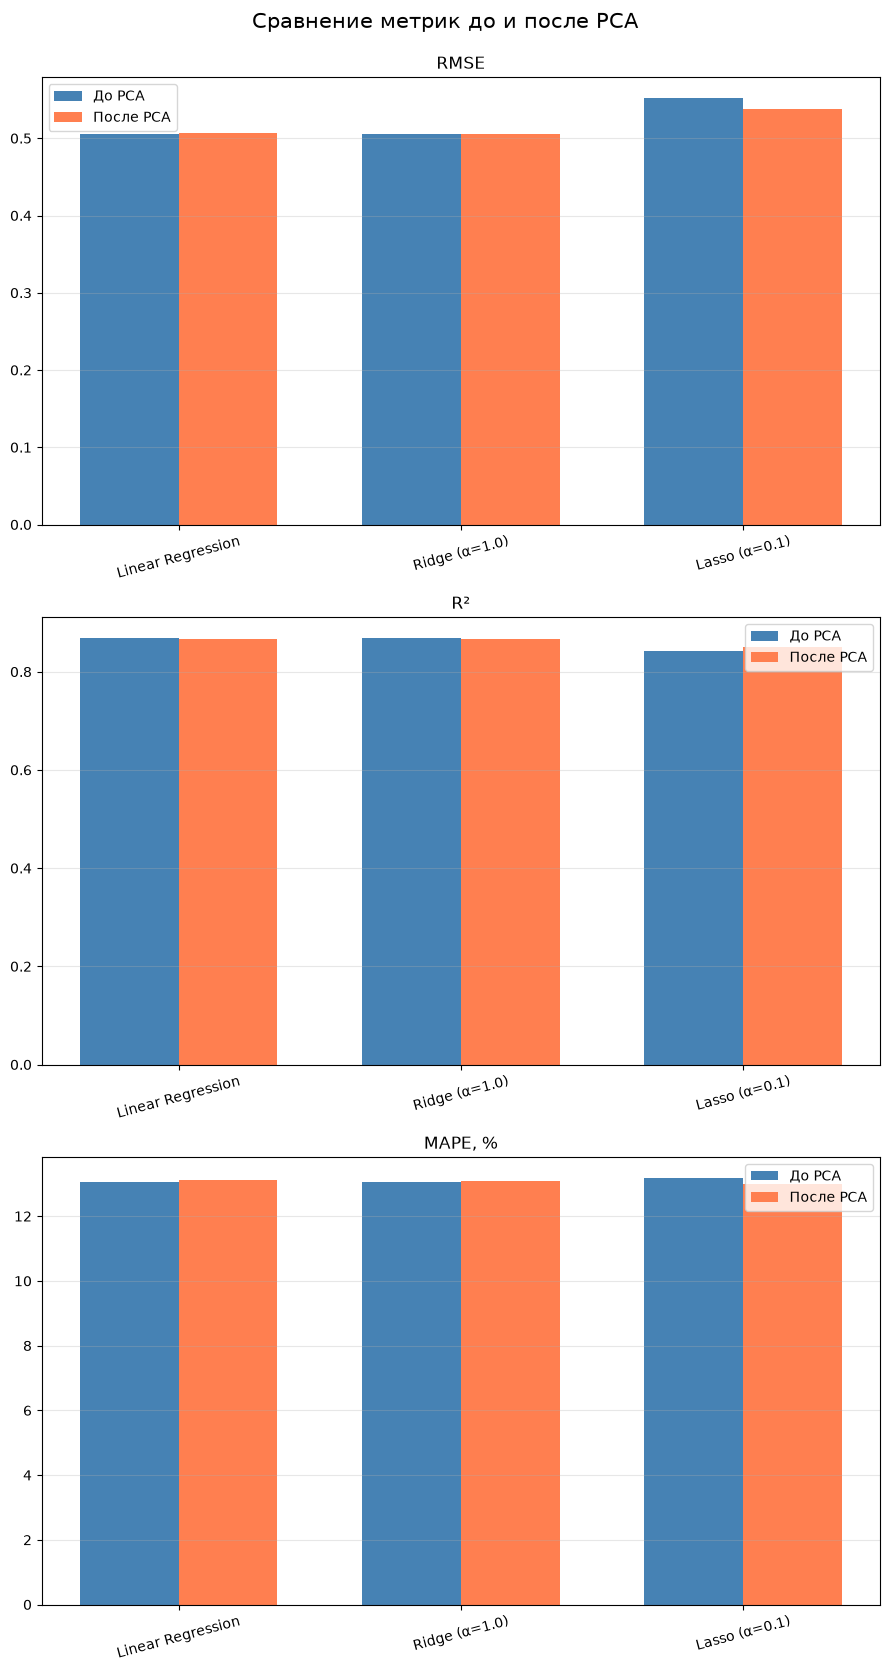

In [413]:
fig, axes = plt.subplots(3, 1, figsize=(9, 17))
for ax, metric in zip(axes, ["RMSE", "R²", "MAPE, %"]):
    x = np.arange(len(metrics_before.index))
    w = 0.35
    ax.bar(x - w/2, metrics_before[metric], w, label="До PCA", color="steelblue")
    ax.bar(x + w/2, metrics_after[metric], w, label="После PCA", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_before.index, rotation=15)
    ax.set_title(metric)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Сравнение метрик до и после PCA\n", fontsize=15)
plt.tight_layout()
plt.show()

На всех трёх диаграммах видно, что столбцы «До PCA» и «После PCA» для Linear и Ridge практически не отличаются – разница в пределах погрешности округления. Это означает, что переход к главным компонентам не ухудшил качество лучших моделей. Для Lasso столбец «После PCA» заметно ниже по RMSE и MAPE и выше по R² – визуально подтверждается улучшение. Таким образом, PCA оказывается положительное влияние.

## **Анализ остатков**

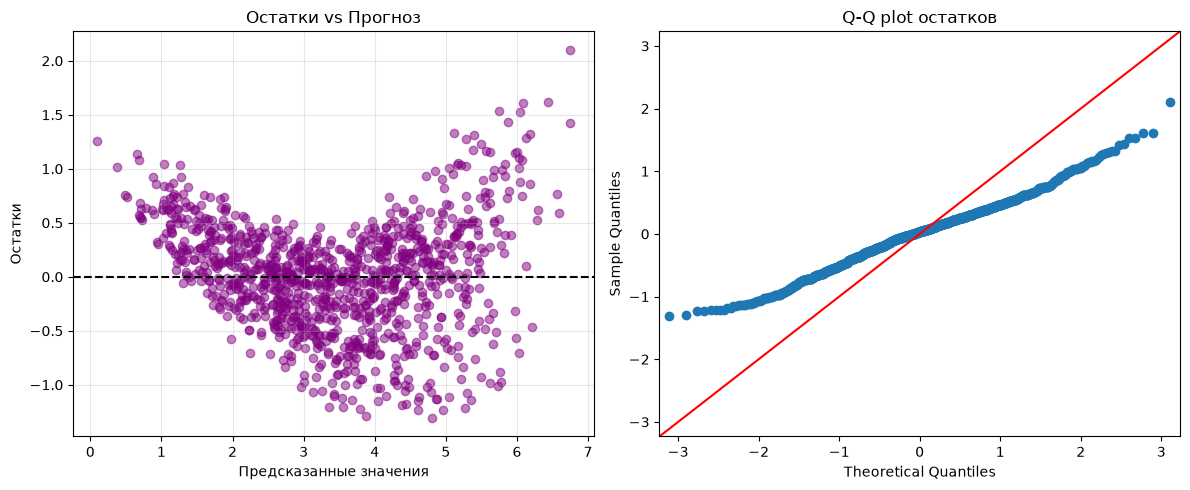

Среднее остатков: 0.00711
Стд. отклонение остатков: 0.50507


In [414]:
import statsmodels.api as sm

best_pred = preds_before["Linear Regression"]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(best_pred, residuals, alpha=0.5, color="purple")
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_xlabel("Предсказанные значения")
axes[0].set_ylabel("Остатки")
axes[0].set_title("Остатки vs Прогноз")
axes[0].grid(alpha=0.3)

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot остатков")
plt.tight_layout()
plt.show()

print(f"Среднее остатков: {residuals.mean():.5f}")
print(f"Стд. отклонение остатков: {residuals.std():.5f}")

Среднее значение остатков близко к нулю, что говорит о несмещенности модели. Однако на графике остатков видна гетероскедастичность (разброс остатков увеличивается с ростом предсказанных значений). Это может указывать на то, что модель хуже предсказывает дорогие автомобили.



In [415]:
from statsmodels.stats.diagnostic import het_breuschpagan

X_test_const = sm.add_constant(X_test_sc)
bp = het_breuschpagan(residuals, X_test_const)
print("Тест Бройша-Пагана:")
print(f"LM-статистика = {bp[0]:.3f}, p-value = {bp[1]:.3e}")
print(f"F-статистика  = {bp[2]:.3f}, p-value = {bp[3]:.3e}")

Тест Бройша-Пагана:
LM-статистика = 92.267, p-value = 1.900e-15
F-статистика  = 11.122, p-value = 1.043e-16


c:\Users\dabac\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


Тест Бройша-Пагана показал p-value < 0.05, что подтверждает наличие гетероскедастичности. Это означает, что стандартные ошибки коэффициентов могут быть недооценены, и для более точного анализа требуется применение робастных стандартных ошибок.

## **Сравнение остатков до и после PCA**

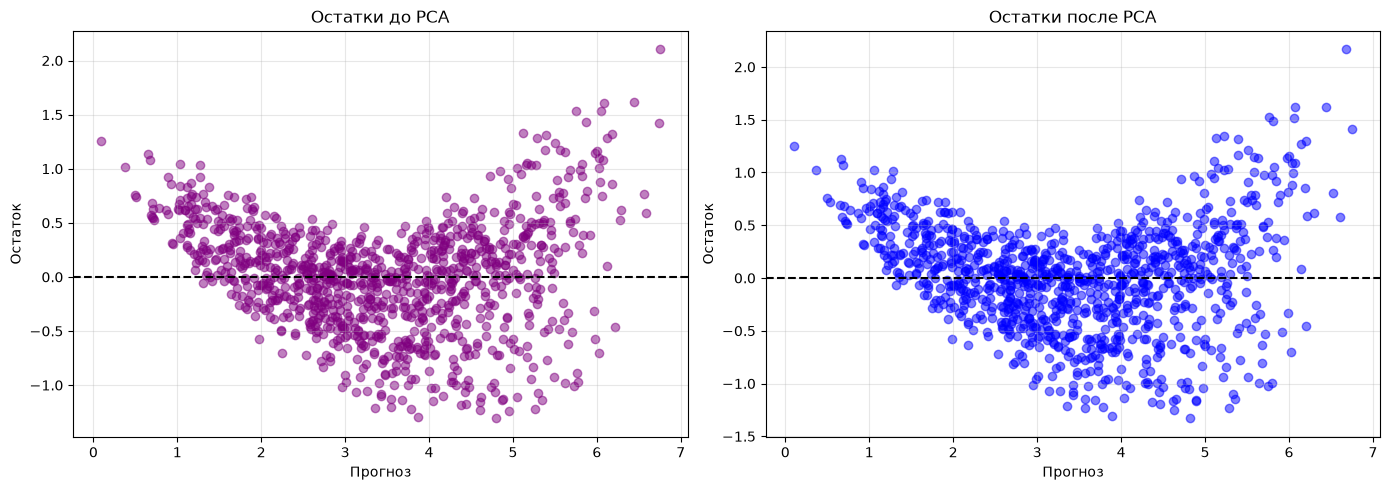

In [416]:
resid_pca = y_test.values - preds_after["Linear Regression"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(preds_before["Linear Regression"], residuals,
                alpha=0.5, color="purple", label="До PCA")
axes[0].axhline(0, linestyle="--", color="black")
axes[0].set_title("Остатки до PCA")
axes[0].set_xlabel("Прогноз")
axes[0].set_ylabel("Остаток")
axes[0].grid(alpha=0.3)

axes[1].scatter(preds_after["Linear Regression"], resid_pca,
                alpha=0.5, color="blue", label="После PCA")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Остатки после PCA")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Остатки от линейной регрессии до и после PCA практически идентичны: в обоих случаях видна гетероскедастичность – разброс ошибок растёт с увеличением прогноза. PCA устранил мультиколлинеарность, но не повлиял на структуру ошибок.

# **Заключение**
В работе построены три регрессионные модели (Linear, Ridge, Lasso) для предсказания цены автомобиля по техническим характеристикам. Исходные данные содержали две выраженные коллинеарные пары (Year/Age_Years, Engine_CC/Horsepower), что подтвердилось корреляционным анализом и расчётом VIF.

Применение PCA сократило пространство признаков с 10 до 7 компонент, сохранив 97% дисперсии. Это устранило мультиколлинеарность без потери предсказательной силы: Linear и Ridge сохранили R² ≈ 0.868, RMSE ≈ 0.506, MAPE ≈ 14.7%. Lasso улучшил R² с 0.843 до 0.851.

Кросс-валидация подтвердила устойчивость результатов: стандартное отклонение R² по фолдам не превышает 0.02. Анализ остатков выявил гетероскедастичность – модель хуже предсказывает дорогие автомобили, что оставляет пространство для дальнейшего улучшения (логарифмирование таргета, робастные ошибки, нелинейные модели).

# **Список источников**

1. Kaggle: Cars Resale Price Dataset – https://www.kaggle.com/datasets/dataseeker25/cars-resale-price-dataset
2. Мультиколлинеарность – https://wiki.loginom.ru/articles/multicollinearity.html
3. Логистическая регрессия: базовые принципы – https://sky.pro/wiki/analytics/logisticheskaya-regressiya-bazovye-printsipy-i-primenenie-v-analize/
4. Кросс-валидация – https://sky.pro/wiki/python/kross-validaciya-chto-eto-i-kak-ispolzovat/

